# Exploring Explainability and Reliability in Brain CT Classification

# 1. Introduction

Medical imaging models can achieve strong predictive performance while still producing **uncertain, poorly calibrated, or incorrect predictions**. In clinical settings, understanding these limitations is important for assessing whether model outputs can be trusted.

This project explores **reliable and explainable AI for brain CT imaging** through an intracranial hemorrhage (ICH) classification task. A patient-level evaluation setup is used to reduce data leakage, while **uncertainty estimation, probability calibration, and Grad-CAM** are used to examine the reliability and interpretability of the classifier.

The project also explores **latent-space perturbations as an initial approach to counterfactual explanation**. Rather than focusing only on predictive performance, the analysis investigates how the model behaves when faced with difficult cases and whether its confidence and explanations provide useful insight into its decisions.

The broader goal is to identify the limitations of these approaches and establish a foundation for further research into **generative methods, diffusion-based explanations, and more robust AI systems for CT imaging**.


# 2. Dataset

## 2.1 Source & Citation

The project uses the **Computed Tomography Images for Intracranial Hemorrhage Detection and Segmentation** dataset introduced by Hssayeni et al. [1].

The dataset contains head CT images from **82 patients**, including patients with and without intracranial hemorrhage (ICH). The scans contain axial CT slices, and hemorrhage regions were annotated by radiologists [1].

For this project, only the **brain-window CT images** are used.

### Reference

[1] Hssayeni, M. (2019). *Computed Tomography Images for Intracranial Hemorrhage Detection and Segmentation*. PhysioNet. doi:10.13026/w8q8-ky94

## 2.2 Task Formulation

The task is formulated as a **binary classification problem**:

- **ICH**: intracranial hemorrhage is present.
- **Non-ICH**: no intracranial hemorrhage is present.

Since multiple CT slices belong to the same patient, the **patient** is used as the unit for data splitting. A patient is labeled as **ICH** if at least one of their slices contains intracranial hemorrhage; otherwise, the patient is labeled **Non-ICH**.

All train, validation, and test splits are performed at the **patient level**, rather than at the individual slice level, to ensure that slices from the same patient do not appear across different splits. Model performance is then evaluated at the **slice level**, with each CT slice treated as an individual prediction.

# 3. Exploratory Data Analysis

Before preparing the data for model training, we examine the organization of the CT images, the available metadata, label distribution, and image characteristics.

The dataset consists primarily of CT image files organized by patient, together with two CSV files that provide supporting metadata: 
* `patient_demographics.csv` contains patient-level information
* `hemorrhage_diagnosis.csv` contains slice-level diagnosis and hemorrhage annotations.

The exploration focuses on:

1. **Patient and slice organization**
2. **Slices per patient**
3. **ICH and Non-ICH distribution and hemorrhage subtypes**
4. **Representative CT slices**

This step provides an overview of the dataset and helps identify relevant characteristics that inform the subsequent modeling pipeline.


In [1]:
from pathlib import Path

from src.data_loading import (
    load_demographics,
    load_diagnosis,
)

DATA_DIR = Path("data")

diagnosis_df = load_diagnosis(DATA_DIR)
demographics_df = load_demographics(DATA_DIR)

print(f"Patients: {len(demographics_df):,}")
print(f"Slice-level records: {len(diagnosis_df):,}")

Patients: 82
Slice-level records: 2,501


## 3.1 Patient and Slice Directory Structure

The CT images are organized by patient, with brain-window slices stored in a separate directory for each patient.

We first verify the number of patient directories and inspect the structure of one representative patient directory.

In [2]:
patients_dir = DATA_DIR / "Patients_CT"

patient_dirs = sorted(
    path for path in patients_dir.iterdir() if path.is_dir()
)

print(f"Number of patient directories: {len(patient_dirs)}")

example_patient = patient_dirs[0]

print(f"\nExample patient: {example_patient.name}")
print("Available windows:", [path.name for path in example_patient.iterdir()])

brain_slices = list((example_patient / "brain").glob("*.jpg"))

print(f"Number of brain-window slices for patient `{example_patient.name}`: {len(brain_slices)}")

Number of patient directories: 82

Example patient: 049
Available windows: ['brain', 'bone']
Number of brain-window slices for patient `049`: 42


## 3.2 Slices-per-Patient Statistics

The number of brain-window slices may vary across patients. We therefore count the available slices for each patient and summarize their distribution.


In [3]:
import pandas as pd

slice_counts = []

for patient_dir in patient_dirs:
    num_slices = len(list((patient_dir / "brain").glob("*.jpg")))

    slice_counts.append(
        {
            "PatientNumber": int(patient_dir.name),
            "NumSlices": num_slices,
        }
    )

slice_counts_df = pd.DataFrame(slice_counts)

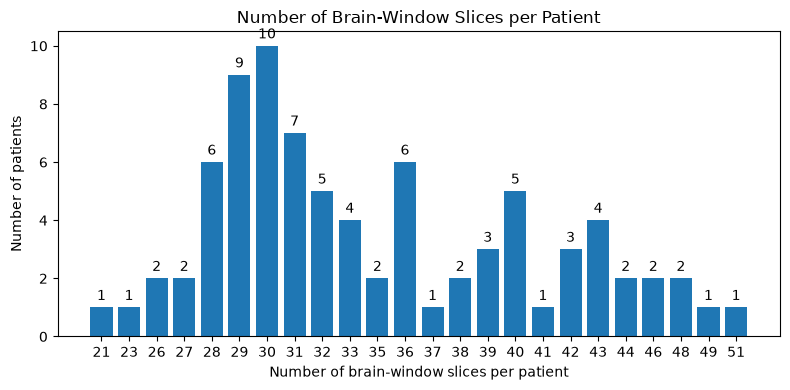

In [4]:
import matplotlib.pyplot as plt

slice_distribution = slice_counts_df["NumSlices"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

bars = plt.bar(
    slice_distribution.index.astype(str),
    slice_distribution.values,
    width=0.8,
)

plt.xlabel("Number of brain-window slices per patient")
plt.ylabel("Number of patients")
plt.title("Number of Brain-Window Slices per Patient")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

The number of brain-window slices varies across patients. This variation reflects differences in the number of axial slices available for each CT scan.

## 3.3 ICH vs. Non-ICH Distribution and Hemorrhage Subtypes

We first examine the distribution of **ICH** and **Non-ICH** slices.

The binary `ICH` label is derived from the `No_Hemorrhage` field, where `1` indicates the presence of intracranial hemorrhage and `0` indicates no hemorrhage.

We then examine the distribution of the five annotated hemorrhage types.

In [5]:
diagnosis_df["ICH"] = 1 - diagnosis_df["No_Hemorrhage"]

label_counts = diagnosis_df["ICH"].value_counts().rename(index={0: "Non-ICH", 1: "ICH"})

label_percentages = (
    diagnosis_df["ICH"]
    .value_counts(normalize=True)
    .rename(index={0: "Non-ICH", 1: "ICH"})
    * 100
)

distribution_df = pd.DataFrame(
    {
        "Count": label_counts,
        "Percentage": label_percentages.round(2),
    }
)

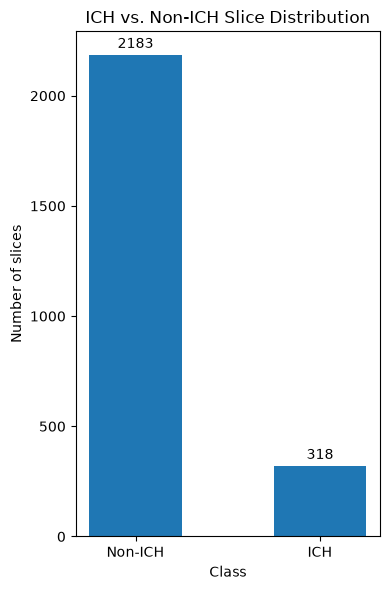

In [6]:
plt.figure(figsize=(4, 6))

bars = plt.bar(
    distribution_df.index,
    distribution_df["Count"],
    width=0.5,
)

plt.xlabel("Class")
plt.ylabel("Number of slices")
plt.title("ICH vs. Non-ICH Slice Distribution")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

In [7]:
hemorrhage_types = [
    "Intraventricular",
    "Intraparenchymal",
    "Subarachnoid",
    "Epidural",
    "Subdural",
]

hemorrhage_type_counts = (
    diagnosis_df[hemorrhage_types].sum().sort_values(ascending=False).rename("Count")
)

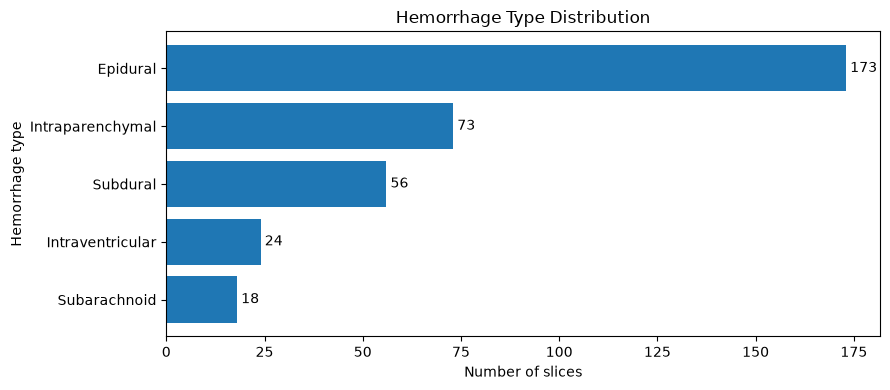

In [8]:
plt.figure(figsize=(9, 4))

bars = plt.barh(
    hemorrhage_type_counts.index,
    hemorrhage_type_counts.values,
)

plt.xlabel("Number of slices")
plt.ylabel("Hemorrhage type")
plt.title("Hemorrhage Type Distribution")

plt.bar_label(bars, padding=3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 3.4 Representative Slice Visualization

We visualize representative brain-window CT slices to inspect their appearance and corresponding metadata.

First, we examine one specific slice together with its slice-level metadata. We then visualize representative **ICH** and **Non-ICH** examples to provide a qualitative view of the two classes.

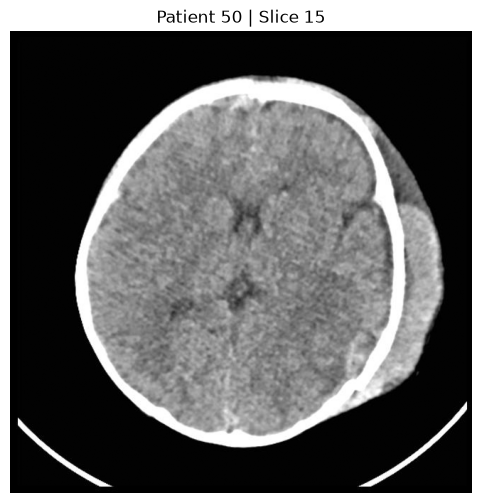

Slice metadata:


PatientNumber       50
SliceNumber         15
Intraventricular     0
Intraparenchymal     1
Subarachnoid         0
Epidural             0
Subdural             0
No_Hemorrhage        0
Fracture_Yes_No      1
ICH                  1
Name: 47, dtype: int64

In [9]:
from src.data_exploration import get_slice_metadata
from src.data_loading import load_ct_image

patient_id = 50
slice_number = 15

image = load_ct_image(
    DATA_DIR,
    patient_id=patient_id,
    slice_number=slice_number,
    window="brain",
)

slice_info = get_slice_metadata(
    diagnosis_df,
    patient_id=patient_id,
    slice_number=slice_number,
)

plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(f"Patient {patient_id} | Slice {slice_number}")

plt.show()

print("Slice metadata:")
display(slice_info)

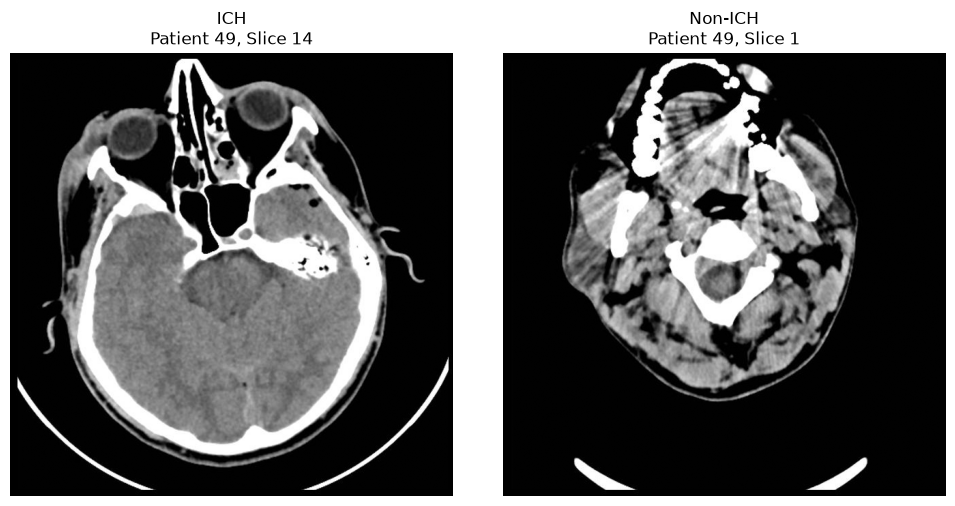

In [10]:
from src.data_exploration import get_example_slices

examples = get_example_slices(diagnosis_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (label, metadata) in zip(axes, examples.items()):
    image = load_ct_image(
        DATA_DIR,
        patient_id=int(metadata["PatientNumber"]),
        slice_number=int(metadata["SliceNumber"]),
        window="brain",
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"{label}\n"
        f"Patient {int(metadata['PatientNumber'])}, "
        f"Slice {int(metadata['SliceNumber'])}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Modeling Approach

The modeling approach is designed for the small number of independent patients and the goal of reliable ICH classification with subsequent uncertainty and explainability analysis.

## 4.1 Classifier Architecture & Rationale

I use an **ImageNet-pretrained ResNet-18** for binary **ICH vs. Non-ICH** classification.

The choice is motivated by:

* **Limited data:** With only **82 patients**, transfer learning is preferred over training from scratch.
* **Model complexity:** ResNet-18 provides sufficient capacity while keeping training computationally manageable.
* **Project focus:** The goal is to obtain a suitable and reproducible classifier for reliability and explainability analysis rather than benchmark multiple architectures.

## 4.2 Patient-Level Train/Validation/Test Split Strategy

Because multiple slices belong to each patient, the **patient** is used as the unit of splitting.

Patients are first divided into a **development set** and a held-out **test set**. The development set is then evaluated using **3-fold cross-validation**.

This prevents slices from the same patient from appearing across different splits and keeps the test set separate from model development.

## 4.3 Preprocessing & Augmentation

The preprocessing pipeline is designed for the ImageNet-pretrained ResNet-18.

* **Resize:** Images are resized to **224 × 224**, matching the model's input size.
* **Channels:** Grayscale CT images are replicated across three channels so the ImageNet-pretrained weights can be used without modifying the input layer.
* **Normalization:** Images are normalized using the **ImageNet mean and standard deviation**.
* **Augmentation:** Training images receive mild horizontal flips, small rotations, and small translations to improve robustness to minor variations.

Augmentation is applied **only to the training data**. Validation and test images use resizing and normalization without augmentation.

## 4.4 Training Configuration

The classifier is **fully fine-tuned** from ImageNet-pretrained weights in a single training stage.

During initial cross-validation, confusion matrices showed that the minority class was not being classified reliably with standard cross-entropy. I therefore use **weighted cross-entropy**, with class weights computed from the training labels of each fold.

The main training choices are:

| Component      | Choice                 | Purpose                                                     |
| -------------- | ---------------------- | ----------------------------------------------------------- |
| Optimizer      | **AdamW**              | Adaptive updates with decoupled weight decay                |
| Learning rate  | $1\times10^{-4}$       | Small updates suitable for fine-tuning pretrained weights   |
| Weight decay   | $1\times10^{-4}$       | Regularization to reduce overfitting                        |
| LR scheduler   | **ReduceLROnPlateau**  | Reduces the learning rate when validation loss plateaus     |
| Early stopping | **Validation loss**    | Stops training when validation loss stops improving         |
| Patience       | **5 epochs**           | Allows temporary fluctuations before stopping               |
| Maximum epochs | **10**                 | Provides enough training time                               |



**Evaluation Metrics** : The main evaluation metrics are **F1-score, AUROC, sensitivity, and specificity**.
* **F1-score** is the main metric because the classes are imbalanced and it balances precision and recall.
* **AUROC** measures the model's ability to distinguish ICH from Non-ICH across classification thresholds.
* **Sensitivity** is important because missing an ICH case is particularly undesirable in this medical classification task.
* **Specificity** is reported to measure the model's ability to correctly identify Non-ICH cases.
* **Validation loss** is used to monitor training dynamics and overfitting and to guide learning-rate scheduling and early stopping.

These choices define the training and validation procedure used throughout the cross-validation experiment.



# 5. Cross-Validation Training

The development set is evaluated using **3-fold stratified cross-validation at the patient level**. A separate ResNet-18 is trained from the ImageNet-pretrained weights for each fold.

## 5.1 Smoke Test

Before running the full experiment, a **one-epoch smoke test** is performed on all three folds.

The purpose is to verify that the data loading, preprocessing, model, loss, optimizer, and training loop work correctly before full training.

In [11]:
import json
from pathlib import Path

import torch
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from src.dataset import CTICHImageDataset
from src.models import create_resnet18
from src.preprocessing import (
    compute_class_weights,
    create_patient_labels,
    create_stratified_folds,
    get_eval_transforms,
    get_train_transforms,
)
from src.training import train_model

# Patient-level split
patient_labels = create_patient_labels(diagnosis_df)

split_path = Path("data/static_patient_split.json")

with open(split_path, "r") as f:
    split = json.load(f)

development_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["development"])
]

test_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["test"])
]

cv_folds = create_stratified_folds(development_patients)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# One-epoch smoke test
for fold in cv_folds:
    fold_number = fold["fold"]

    print(f"\n{'=' * 20} Fold {fold_number} {'=' * 20}")

    train_patient_ids = fold["train"]["PatientNumber"].tolist()
    validation_patient_ids = fold["validation"]["PatientNumber"].tolist()

    train_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=train_patient_ids,
        transform=get_train_transforms(),
    )

    validation_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=validation_patient_ids,
        transform=get_eval_transforms(),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=32,
        shuffle=False,
    )

    model = create_resnet18(num_classes=2).to(device)

    train_labels = fold["train"]["ICH"].values
    class_weights = compute_class_weights(train_labels).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    train_model(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=1,
        patience=5,
    )

print("\nSmoke test completed successfully for all 3 folds.")


Using device: cpu

==================== Fold 1 ====================
Epoch 01/1 | Train Loss: 0.4077 | Train F1: 0.4424 | Val Loss: 0.3275 | Val F1: 0.3818 | Val Sensitivity: 0.2692 | Val Specificity: 0.9811 | Val AUROC: 0.7864 | LR: 1.00e-04

==================== Fold 2 ====================
Epoch 01/1 | Train Loss: 0.2976 | Train F1: 0.4016 | Val Loss: 0.5789 | Val F1: 0.0678 | Val Sensitivity: 0.0351 | Val Specificity: 1.0000 | Val AUROC: 0.8134 | LR: 1.00e-04

==================== Fold 3 ====================
Epoch 01/1 | Train Loss: 0.5088 | Train F1: 0.4021 | Val Loss: 0.2812 | Val F1: 0.1176 | Val Sensitivity: 0.0625 | Val Specificity: 1.0000 | Val AUROC: 0.8225 | LR: 1.00e-04

Smoke test completed successfully for all 3 folds.


The smoke test completed successfully for all three folds. The data pipeline, model, loss, optimizer, and training loop executed correctly, allowing the full cross-validation training to proceed.

## 5.2 Full 3-Fold Cross-Validation

For each fold, the model is trained on the training patients and evaluated on the corresponding validation patients.

The training configuration defined in Section 4.4 is used, including weighted cross-entropy, AdamW, learning-rate scheduling, and early stopping.

The held-out test patients remain completely separate from cross-validation and are reserved for the final evaluation.

In [12]:
# Training configuration
BATCH_SIZE = 32
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

NUM_WORKERS = 4


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

print(f"Using device: {device}")


# Train a separate model on each fold
fold_results = {}

for fold in cv_folds:
    fold_number = fold["fold"]

    print(f"\n{'=' * 20} Fold {fold_number} {'=' * 20}")

    train_patient_ids = fold["train"]["PatientNumber"].tolist()
    validation_patient_ids = fold["validation"]["PatientNumber"].tolist()

    train_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=train_patient_ids,
        transform=get_train_transforms(),
    )

    validation_dataset = CTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=validation_patient_ids,
        transform=get_eval_transforms(),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = create_resnet18(num_classes=2).to(device)

    train_labels = fold["train"]["ICH"].values

    class_weights = compute_class_weights(train_labels).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
    )

    (
        model,
        history,
        best_validation_predictions,
        epoch_states,
        best_epoch,
    ) = train_model(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        checkpoint_metric="f1",
    )

    fold_results[fold_number] = {
        "model": model,
        "history": history,
        "best_validation_predictions": best_validation_predictions,
        "epoch_states": epoch_states,
        "best_epoch": best_epoch,
        "train_patient_ids": train_patient_ids,
        "validation_patient_ids": validation_patient_ids,
    }

print("\nFull cross-validation training completed.")

Using device: cpu

==================== Fold 1 ====================
Epoch 01/10 | Train Loss: 0.3341 | Train F1: 0.4845 | Val Loss: 0.6172 | Val F1: 0.0000 | Val Sensitivity: 0.0000 | Val Specificity: 1.0000 | Val AUROC: 0.6767 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.2010 | Train F1: 0.7359 | Val Loss: 0.3494 | Val F1: 0.3826 | Val Sensitivity: 0.2821 | Val Specificity: 0.9743 | Val AUROC: 0.8160 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1489 | Train F1: 0.7967 | Val Loss: 0.3745 | Val F1: 0.2887 | Val Sensitivity: 0.1795 | Val Specificity: 0.9914 | Val AUROC: 0.8221 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1244 | Train F1: 0.8385 | Val Loss: 0.5767 | Val F1: 0.1379 | Val Sensitivity: 0.0769 | Val Specificity: 0.9949 | Val AUROC: 0.7556 | LR: 1.00e-04
Epoch 05/10 | Train Loss: 0.1023 | Train F1: 0.8673 | Val Loss: 0.5649 | Val F1: 0.2292 | Val Sensitivity: 0.1410 | Val Specificity: 0.9880 | Val AUROC: 0.7624 | LR: 5.00e-05
Epoch 06/10 | Train Loss: 0.0834 | Train F1: 0.8927 | Val

## 5.3 Aggregated CV Performance

The three folds show some variation in validation performance, particularly in F1-score and sensitivity. The model also tends to fit the training data quickly, while validation performance improves less consistently, suggesting **early overfitting**.

A possible explanation is the relatively small number of patients available in each training fold. This may make the model more sensitive to patient-level differences and lead to less stable validation performance. This remains a **hypothesis to examine during final training and evaluation**.

The cross-validation stage also guided several modeling decisions, including the **transfer-learning strategy, loss function, training configuration, and evaluation metrics**. These choices were assessed based on their behavior across patient-level folds rather than on a single split.

The selected configuration is therefore used in the next stage to train the **final model on the full development set**, followed by evaluation on the held-out test set.

# 6. Final Model & Test-Set Evaluation

After completing 3-fold cross-validation, we train the final classifier using all **65 development patients**.

The training configuration selected during cross-validation is retained for the final model. Since the final model uses the full development set, no validation split is used at this stage.

The **17 test patients remain completely unseen** during training and are used only for the final evaluation.

The final evaluation provides a single performance estimate on the held-out patient-level test set.

### 6.1 Final Model Training

The final classifier is trained once on the **full development set** using the configuration selected through 3-fold cross-validation.

Validation data is used during cross-validation for model and training decisions, including early stopping and checkpoint selection. Once these decisions are fixed, the final model is trained on **all development patients**, with a fixed number of epochs and no validation set or early stopping.

The held-out test set remains untouched until final evaluation.


In [13]:
development_patient_ids = development_patients["PatientNumber"].tolist()

train_dataset = CTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=development_patient_ids,
    transform=get_train_transforms(),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

model = create_resnet18(num_classes=2).to(device)

# Class weights from all development patients
train_labels = development_patients["ICH"].values

class_weights = compute_class_weights(train_labels).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Final training: no validation, no early stopping
model, history, _, epoch_states, final_epoch = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=None,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=None,
    checkpoint_metric=None,
)

print("\nFinal model training completed.")

Epoch 01/10 | Train Loss: 0.3430 | Train F1: 0.4179 | Train Sensitivity: 0.3828 | Train Specificity: 0.9334 | Train AUROC: 0.8227 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.2204 | Train F1: 0.6352 | Train Sensitivity: 0.5781 | Train Specificity: 0.9641 | Train AUROC: 0.9352 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1735 | Train F1: 0.7444 | Train Sensitivity: 0.7109 | Train Specificity: 0.9705 | Train AUROC: 0.9626 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1526 | Train F1: 0.7629 | Train Sensitivity: 0.7227 | Train Specificity: 0.9745 | Train AUROC: 0.9700 | LR: 1.00e-04
Epoch 05/10 | Train Loss: 0.1379 | Train F1: 0.8094 | Train Sensitivity: 0.8047 | Train Specificity: 0.9728 | Train AUROC: 0.9732 | LR: 1.00e-04
Epoch 06/10 | Train Loss: 0.1176 | Train F1: 0.8120 | Train Sensitivity: 0.7930 | Train Specificity: 0.9763 | Train AUROC: 0.9827 | LR: 1.00e-04
Epoch 07/10 | Train Loss: 0.0991 | Train F1: 0.8606 | Train Sensitivity: 0.8438 | Train Specificity: 0.9826 | Train AUROC: 0.9875 

## 6.2 Test-Set Evaluation

The final model is evaluated on the **17 held-out test patients**.

This evaluation provides the final estimate of model performance on previously unseen patients. The analysis includes standard classification metrics, a confusion matrix, and an ROC curve.

In [14]:
from src.training import evaluate_model

SELECTED_THRESHOLD = 0.5

test_patient_ids = set(
    test_patients["PatientNumber"]
)

# Test dataset
test_dataset = CTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=test_patient_ids,
    transform=get_eval_transforms(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"\nNumber of test slices: {len(test_dataset)}")


# Final test evaluation
model.eval()

test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    threshold=SELECTED_THRESHOLD
)

print("\nTest results:")
for metric, value in test_results["metrics"].items():
    print(f"{metric}: {value:.4f}")


Number of test slices: 518

Test results:
accuracy: 0.8803
f1: 0.3800
sensitivity: 0.3065
specificity: 0.9583
auroc: 0.8659


The model achieves a relatively high **accuracy of 88.03%**, but this metric can be misleading because the dataset is imbalanced toward Non-ICH cases.

The **38.00% sensitivity** shows that the model correctly detects only a small proportion of ICH cases. Therefore, despite its high overall accuracy, the model is currently **not reliable for detecting ICH**.


## 6.3 Test-Set Results

The model shows substantially higher specificity (**95.83%**) than sensitivity (**38.00%**). The confusion matrix shows that the model correctly identifies most Non-ICH slices, but misses a considerable proportion of ICH slices.

Overall, the results indicate that **ICH detection remains a major limitation of the current classifier**.

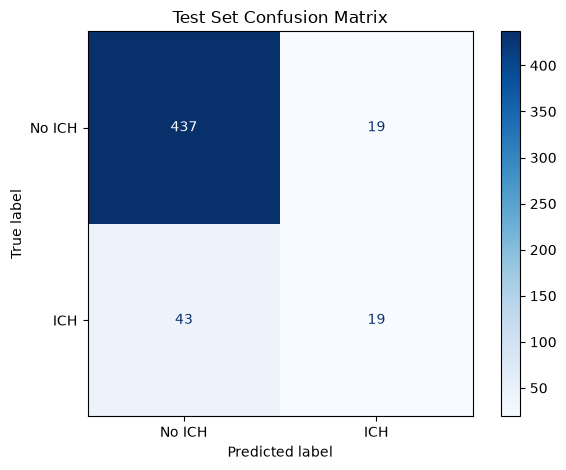

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix

labels = test_results["labels"]
predictions = test_results["predictions"]

cm = confusion_matrix(labels, predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No ICH", "ICH"],
).plot(cmap="Blues")

plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


**The confusion matrix :** highlights the main limitation of the model. While it correctly classifies most Non-ICH slices (**437/456**), it detects only **19 of 62 ICH slices**, resulting in **43 false negatives**.

This corresponds to a sensitivity of **38.00%**, indicating that the model misses a large proportion of ICH cases. In a medical screening context, this is a significant limitation and motivates further investigation of the false-negative predictions.

**The ROC curve :** evaluates the model's ability to distinguish **ICH from Non-ICH** across different classification thresholds.

It plots **sensitivity (true positive rate)** against the **false positive rate**. The **AUROC** summarizes the model's overall discriminative ability, with higher values indicating better separation between the two classes.


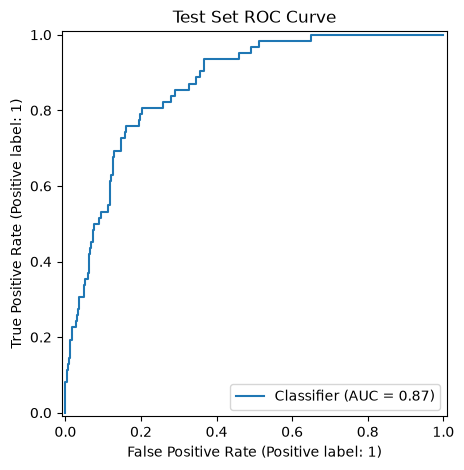

In [16]:
probabilities = test_results["probabilities"]
RocCurveDisplay.from_predictions(
    labels,
    probabilities,
)

plt.title("Test Set ROC Curve")
plt.tight_layout()
plt.show()

The ROC curve gives an AUROC of **0.86**, indicating that the model retains a moderate ability to distinguish ICH from Non-ICH across different decision thresholds. The predicted probabilities also show that many samples are assigned probabilities close to 0 or 1, while a smaller group receives intermediate probabilities.

This suggests that the model can separate many cases clearly, but struggles with a subset of more difficult cases. These predictions are particularly interesting to examine in the subsequent reliability and uncertainty analysis.

# 7. Model Reliability

Good classification performance alone does not indicate whether a model's predictions can be trusted.

In a medical setting, it is also important to understand **how confident the model is in its predictions** and whether its confidence reflects its actual reliability.

This section examines two aspects of model reliability:

1. **Calibration:** whether predicted probabilities correspond to observed outcomes.
2. **Uncertainty:** whether incorrect or difficult predictions are associated with higher uncertainty.

### 7.1 Probability Calibration

The classifier outputs a probability of ICH for each CT slice. A well-calibrated model should produce probabilities that reflect the observed frequency of the corresponding outcomes.

For example, among predictions with an estimated probability of 0.8, approximately 80% should correspond to ICH cases.

We evaluate calibration using the **Brier score** and **Expected Calibration Error (ECE)**.

The Brier score measures how close the predicted probabilities are to the actual outcomes, while ECE measures the average gap between predicted confidence and observed accuracy across groups of predictions.

In [17]:
import numpy as np
from sklearn.metrics import brier_score_loss

from src.uncertainty import expected_calibration_error

labels = np.asarray(test_results["labels"])
probabilities = np.asarray(test_results["probabilities"])

# Brier score
brier = brier_score_loss(labels, probabilities)
ece = expected_calibration_error(
    labels,
    probabilities,
)

print(f"Brier score: {brier:.4f}")
print(f"ECE: {ece:.4f}")


Brier score: 0.0945
ECE: 0.0769


The model's probabilities are not perfectly calibrated, but the calibration metrics suggest that they provide useful information about prediction confidence. However, a high-confidence prediction is not guaranteed to be correct, so the probabilities should still be interpreted with caution.

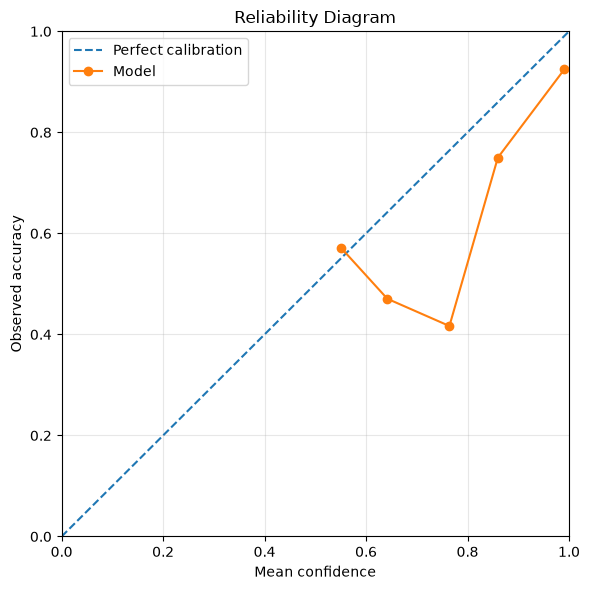

In [18]:
labels = np.asarray(test_results["labels"])
probabilities = np.asarray(test_results["probabilities"])

predictions = (probabilities >= 0.5).astype(int)

confidence = np.where(
    predictions == 1,
    probabilities,
    1 - probabilities,
)

correctness = (predictions == labels).astype(float)

n_bins = 10
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

bin_confidences = []
bin_accuracies = []

for i in range(n_bins):
    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    if i == 0:
        in_bin = (confidence >= lower) & (confidence <= upper)
    else:
        in_bin = (confidence > lower) & (confidence <= upper)

    if np.any(in_bin):
        bin_confidences.append(confidence[in_bin].mean())
        bin_accuracies.append(correctness[in_bin].mean())
    else:
        bin_confidences.append(np.nan)
        bin_accuracies.append(np.nan)

plt.figure(figsize=(6, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.plot(
    bin_confidences,
    bin_accuracies,
    marker="o",
    label="Model",
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Mean confidence")
plt.ylabel("Observed accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The reliability diagram shows that the model is **not perfectly calibrated**. Predictions with lower confidence are relatively close to the ideal calibration line, while higher-confidence predictions tend to lie below it, indicating **overconfidence**.

For example, predictions with an average confidence of about **99%** have an observed accuracy of about **94%**. This means that even very confident predictions are not always correct.

Together with the **Brier score of 0.0945** and **ECE of 0.0769**, the results suggest that the model's probabilities provide useful confidence information but should **not be interpreted as perfectly reliable probabilities**.


### 7.2 Uncertainty with MC Dropout

To explore predictive uncertainty, we use **Monte Carlo Dropout (MC Dropout)** during inference.

The model produces multiple predictions for the same image while dropout is enabled. The variation between these predictions provides an estimate of predictive uncertainty.

We then compare uncertainty between **correct and incorrect predictions** and examine individual cases where the model is uncertain or confidently wrong.

In [19]:
from src.uncertainty import collect_uncertainty_predictions

uncertainty_results = collect_uncertainty_predictions(
    model=model,
    data_loader=test_loader,
    device=device,
    n_samples=20,
)

print(f"Test slices: {len(uncertainty_results['labels'])}")
print(
    f"Mean uncertainty: "
    f"{torch.tensor(uncertainty_results['uncertainties']).mean():.4f}"
)

labels = np.asarray(uncertainty_results["labels"])
predictions = np.asarray(uncertainty_results["predictions"])
uncertainties = np.asarray(uncertainty_results["uncertainties"])

correct = predictions == labels
incorrect = ~correct

mean_uncertainty_correct = uncertainties[correct].mean()
mean_uncertainty_incorrect = uncertainties[incorrect].mean()

print(f"Correct predictions:   {correct.sum()}")
print(f"Incorrect predictions: {incorrect.sum()}")
print(f"Mean uncertainty (correct):   {mean_uncertainty_correct:.4f}")
print(f"Mean uncertainty (incorrect): {mean_uncertainty_incorrect:.4f}")

Test slices: 518
Mean uncertainty: 0.0154
Correct predictions:   454
Incorrect predictions: 64
Mean uncertainty (correct):   0.0104
Mean uncertainty (incorrect): 0.0506


MC Dropout uncertainty is higher for incorrect predictions, suggesting that it provides useful information about prediction difficulty. However, some ICH false negatives remain highly confident and have very low uncertainty, showing that uncertainty alone cannot guarantee safe detection.

In [20]:
# Indices of the 5 most uncertain predictions
most_uncertain = np.argsort(uncertainties)[-5:][::-1]

print("\nMost uncertain predictions:")
for idx in most_uncertain:
    print(
        f"Index {idx}: "
        f"Actual={labels[idx]}, "
        f"Predicted={predictions[idx]}, "
        f"P(ICH)={uncertainty_results['probabilities'][idx]:.4f}, "
        f"Uncertainty={uncertainties[idx]:.4f}, "
        f"{'CORRECT' if correct[idx] else 'INCORRECT'}"
    )

incorrect_indices = np.where(incorrect)[0]
confidently_wrong = incorrect_indices[
    np.argsort(uncertainties[incorrect_indices])
][:5]

print("\nMost confident incorrect predictions:")
for idx in confidently_wrong:
    print(
        f"Index {idx}: "
        f"Actual={labels[idx]}, "
        f"Predicted={predictions[idx]}, "
        f"P(ICH)={uncertainty_results['probabilities'][idx]:.4f}, "
        f"Uncertainty={uncertainties[idx]:.4f}"
    )


Most uncertain predictions:
Index 209: Actual=1, Predicted=1, P(ICH)=0.6095, Uncertainty=0.1584, CORRECT
Index 23: Actual=1, Predicted=0, P(ICH)=0.4366, Uncertainty=0.1449, INCORRECT
Index 498: Actual=0, Predicted=0, P(ICH)=0.3941, Uncertainty=0.1394, CORRECT
Index 500: Actual=0, Predicted=1, P(ICH)=0.6218, Uncertainty=0.1344, INCORRECT
Index 497: Actual=0, Predicted=0, P(ICH)=0.2207, Uncertainty=0.1315, CORRECT

Most confident incorrect predictions:
Index 169: Actual=1, Predicted=0, P(ICH)=0.0004, Uncertainty=0.0003
Index 168: Actual=1, Predicted=0, P(ICH)=0.0015, Uncertainty=0.0008
Index 329: Actual=0, Predicted=1, P(ICH)=0.9985, Uncertainty=0.0009
Index 330: Actual=0, Predicted=1, P(ICH)=0.9978, Uncertainty=0.0009
Index 170: Actual=1, Predicted=0, P(ICH)=0.0019, Uncertainty=0.0010


Uncertainty is informative about prediction difficulty, but it is not sufficient to identify all errors. Some important ICH false negatives remain highly confident and low-uncertainty.

### 7.3 Reliability Analysis

* **Uncertainty:** Incorrect predictions have higher average uncertainty than correct predictions (0.0432 vs. 0.0120).
* **What this means:** The model is generally less certain when making incorrect predictions, suggesting that uncertainty can indicate prediction difficulty.
* **Important limitation:** Some ICH false negatives remain **highly confident with very low uncertainty**.
* **Overall:** Uncertainty can identify some difficult cases, but it **cannot reliably detect all model errors**.

The calibration analysis indicates that the model is somewhat overconfident. To improve the reliability of its predicted probabilities, we apply temperature scaling as a post-hoc calibration method.

## 7.4 Temperature Scaling

The calibration analysis showed that the model's predicted probabilities were somewhat overconfident. We therefore apply **temperature scaling**, a post-hoc calibration method that adjusts the model's logits without retraining the classifier.

The temperature is learned from the **out-of-fold (OOF) predictions** generated during 3-fold cross-validation. The learned temperature is then applied to the final model's test logits to obtain calibrated probabilities.


In [21]:
from src.uncertainty import fit_temperature

oof_logits = []
oof_labels = []

for fold_number, results in fold_results.items():

    validation_predictions = results["best_validation_predictions"]

    oof_logits.extend(validation_predictions["logits"])
    oof_labels.extend(validation_predictions["labels"])

oof_logits = torch.tensor(
    oof_logits,
    dtype=torch.float32,
)

oof_labels = torch.tensor(
    oof_labels,
    dtype=torch.long,
)

print(f"OOF samples: {len(oof_labels)}")

temperature = fit_temperature(
    oof_logits,
    oof_labels,
)

print(f"Learned temperature: {temperature:.4f}")

scaled_oof_logits = oof_logits / temperature

calibrated_oof_probabilities = torch.softmax(
    scaled_oof_logits,
    dim=1,
)[:, 1]

calibrated_oof_probabilities = (
    calibrated_oof_probabilities.cpu().numpy()
)

OOF samples: 1983


/tmp/ipykernel_30189/168472170.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  oof_logits = torch.tensor(


Learned temperature: 1.1381


In [22]:
model.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        all_logits.append(outputs.cpu())
        all_labels.append(labels.cpu())

test_logits = torch.cat(all_logits).numpy()
test_labels = torch.cat(all_labels).numpy()

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1,
)[:, 1].numpy()

test_predictions = (test_probabilities >= 0.5).astype(int)

test_results = {
    "labels": test_labels,
    "predictions": test_predictions,
    "probabilities": test_probabilities,
    "logits": test_logits,
}

In [23]:
test_logits = torch.tensor(
    test_results["logits"],
    dtype=torch.float32,
)

scaled_test_logits = test_logits / temperature

calibrated_test_probabilities = torch.softmax(
    scaled_test_logits,
    dim=1,
)[:, 1].numpy()

calibrated_test_predictions = (
    calibrated_test_probabilities >= 0.5
).astype(int)

In [24]:
import numpy as np
from sklearn.metrics import brier_score_loss

from src.uncertainty import expected_calibration_error

test_labels = np.asarray(test_results["labels"])
test_probabilities = np.asarray(test_results["probabilities"])

test_logits = torch.tensor(
    test_results["logits"],
    dtype=torch.float32,
)

calibrated_test_probabilities = torch.softmax(
    test_logits / temperature,
    dim=1,
)[:, 1].cpu().numpy()

brier_test_before = brier_score_loss(
    test_labels,
    test_probabilities,
)

ece_test_before = expected_calibration_error(
    test_labels,
    test_probabilities,
)

brier_test_after = brier_score_loss(
    test_labels,
    calibrated_test_probabilities,
)

ece_test_after = expected_calibration_error(
    test_labels,
    calibrated_test_probabilities,
)

print("Test Set - Before Temperature Scaling:")
print(f"Brier score: {brier_test_before:.4f}")
print(f"ECE:         {ece_test_before:.4f}")

print("\nTest Set - After Temperature Scaling:")
print(f"Temperature: {temperature:.4f}")
print(f"Brier score: {brier_test_after:.4f}")
print(f"ECE:         {ece_test_after:.4f}")

Test Set - Before Temperature Scaling:
Brier score: 0.0945
ECE:         0.0769

Test Set - After Temperature Scaling:
Temperature: 1.1381
Brier score: 0.0923
ECE:         0.0690


Temperature scaling **slightly improved the Brier score** and **reduced the ECE**, indicating slightly improved calibration of the OOF predictions.


# 8. Error Analysis & Explainability

The test-set results show that the classifier makes both **false positive and false negative errors**. This section examines selected misclassifications in more detail to better understand the model's behavior.

We combine **uncertainty analysis** with **Grad-CAM visualizations** to investigate both how confident the model is and which image regions contribute to its predictions.

### 8.1 Selecting Representative Errors

Rather than analyzing all misclassified slices, two representative errors are selected for detailed analysis:

* **One false negative:** an ICH slice incorrectly classified as Non-ICH.
* **One false positive:** a Non-ICH slice incorrectly classified as ICH.

To make the selection explicit, we choose the **most confident error** from each category. This allows us to examine cases where the model is strongly confident despite making an incorrect prediction.

These two cases are then analyzed using **MC Dropout uncertainty** and **Grad-CAM** to investigate the model's confidence and visual evidence.


In [26]:
labels = np.asarray(test_results["labels"])
predictions = np.asarray(test_results["predictions"])
probabilities = np.asarray(test_results["probabilities"])

misclassified_indices = np.where(labels != predictions)[0]

# Separate error types
false_negative_indices = misclassified_indices[
    (labels[misclassified_indices] == 1) & (predictions[misclassified_indices] == 0)
]

false_positive_indices = misclassified_indices[
    (labels[misclassified_indices] == 0) & (predictions[misclassified_indices] == 1)
]

# Select the most confident error from each category
fn_idx = false_negative_indices[np.argmax(1 - probabilities[false_negative_indices])]

fp_idx = false_positive_indices[np.argmax(probabilities[false_positive_indices])]

selected_indices = [fn_idx, fp_idx]

selected_errors = test_dataset.samples.iloc[selected_indices].copy()

selected_errors["Prediction"] = predictions[selected_indices]
selected_errors["Probability_ICH"] = probabilities[selected_indices]

selected_errors["Error"] = [
    "False Negative",
    "False Positive",
]

selected_errors = selected_errors[
    [
        "PatientNumber",
        "SliceNumber",
        "ICH",
        "Prediction",
        "Probability_ICH",
        "Error",
    ]
].reset_index(drop=True)

print("Selected representative errors:")
display(selected_errors)

Selected representative errors:


,PatientNumber,SliceNumber,ICH,Prediction,Probability_ICH,Error
0,74,14,1,0,0.000446,False Negative
1,95,17,0,1,0.998524,False Positive


Two representative misclassifications are selected:

1. **Patient 75, slice 16:** false negative, with ICH incorrectly classified as Non-ICH.
2. **Patient 95, slice 17:** false positive, with Non-ICH incorrectly classified as ICH.

Both cases are high-confidence errors, making them useful for investigating the limitations of the model's confidence and visual reasoning.


In [27]:
selected_errors = [
    {
        "patient": int(row["PatientNumber"]),
        "slice": int(row["SliceNumber"]),
        "actual_label": int(row["ICH"]),
    }
    for _, row in selected_errors.iterrows()
]
selected_samples = []

for item in selected_errors:
    sample = test_dataset.samples[
        (test_dataset.samples["PatientNumber"] == item["patient"])
        & (test_dataset.samples["SliceNumber"] == item["slice"])
    ].iloc[0]

    selected_samples.append(sample)

In [28]:
from src.uncertainty import mc_dropout_predict

images = []

for sample in selected_samples:
    image = load_ct_image(
        DATA_DIR,
        patient_id=int(sample["PatientNumber"]),
        slice_number=int(sample["SliceNumber"]),
        window="brain",
    )

    image = get_eval_transforms()(image)
    images.append(image)

images = torch.stack(images)

mc_results = mc_dropout_predict(
    model=model,
    images=images,
    device=device,
    n_samples=20,
)

for i, sample in enumerate(selected_samples):
    print(
        f"Patient {int(sample['PatientNumber'])}, "
        f"Slice {int(sample['SliceNumber'])} | "
        f"Actual: {int(sample['ICH'])} | "
        f"Prediction: {int(mc_results['predictions'][i])} | "
        f"Probability: {mc_results['probabilities'][i].item():.6f} | "
        f"Uncertainty: {mc_results['uncertainty'][i].item():.4f}"
    )

model.eval();

Patient 74, Slice 14 | Actual: 1 | Prediction: 0 | Probability: 0.000524 | Uncertainty: 0.0005
Patient 95, Slice 17 | Actual: 0 | Prediction: 1 | Probability: 0.998670 | Uncertainty: 0.0008


### 8.2 MC Dropout Analysis of Representative Errors

* **Patient 80, slice 9:** false negative, with P(ICH) = **0.0013**. The model strongly predicts Non-ICH despite the presence of ICH.
* **Patient 50, slice 14:** false positive, with P(ICH) = **0.991909**. The model strongly predicts ICH despite the absence of hemorrhage.

The two cases illustrate that the model can produce **very high-confidence incorrect predictions** in both directions. MC Dropout uncertainty is used next to determine whether these predictions are also stable across stochastic forward passes.

MC Dropout provides information about the **stability of the prediction**. Grad-CAM is then used to investigate **which regions of the CT image contribute to the prediction**.


### 8.3 Grad-CAM Visualization

Grad-CAM is used to visualize the image regions that contribute most to the model's **ICH prediction**.

For the two selected errors, we compare the highlighted regions with the actual CT images to investigate whether the model focuses on **relevant intracranial regions** or relies on potentially misleading visual features.

The Grad-CAM target is set to the **ICH class (class 1)** for both cases, allowing us to examine the evidence associated with the ICH prediction even when the model ultimately predicts Non-ICH.


In [29]:
from src.explainability import GradCAM

model.eval()
grad_cam = GradCAM(
    model=model,
    target_layer=model.layer4[-1],
)

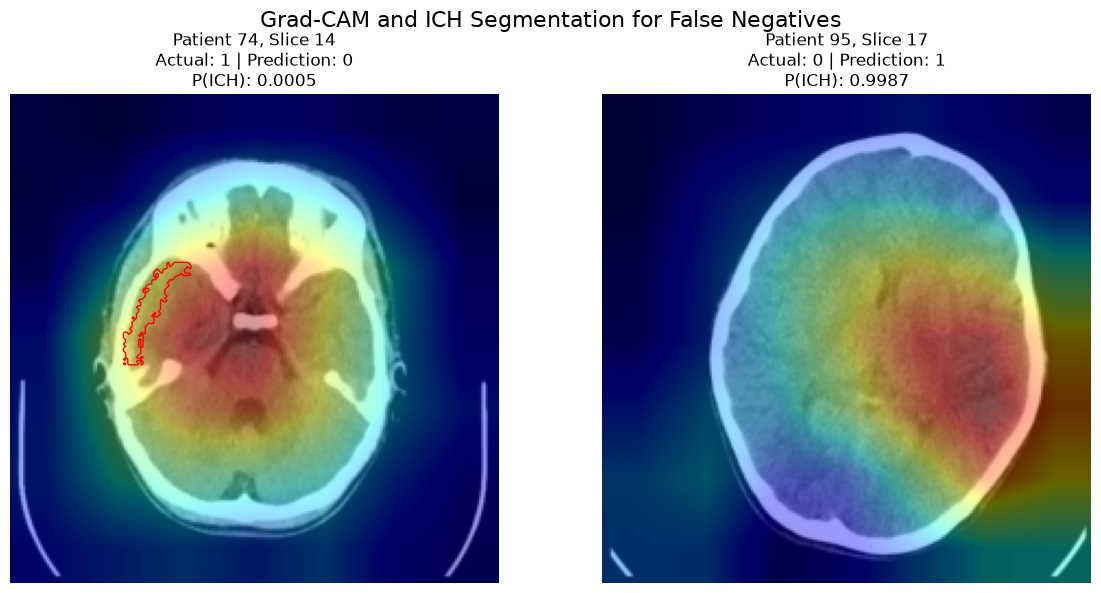

In [30]:
from pathlib import Path

import torch.nn.functional as F
from PIL import Image

fig, axes = plt.subplots(
    1,
    len(selected_samples),
    figsize=(6 * len(selected_samples), 6),
)

if len(selected_samples) == 1:
    axes = [axes]

# ImageNet normalization
mean = 0.485
std = 0.229

for i, sample in enumerate(selected_samples):
    patient_id = int(sample["PatientNumber"])
    slice_id = int(sample["SliceNumber"])
    actual = int(sample["ICH"])

    prediction = int(mc_results["predictions"][i])
    probability = mc_results["probabilities"][i].item()

    # Image

    image = images[i].unsqueeze(0).to(device)

    # Grad-CAM

    cam, output = grad_cam.generate(
        image=image,
        target_class=prediction,
    )

    cam_resized = F.interpolate(
        cam,
        size=(224, 224),
        mode="bilinear",
        align_corners=False,
    )

    cam_resized = cam_resized.squeeze().detach().cpu().numpy()

    # Undo ImageNet normalization

    image_np = images[i][0].detach().cpu().numpy()
    image_np = image_np * std + mean
    image_np = image_np.clip(0, 1)

    # Plot original CT

    axes[i].imshow(
        image_np,
        cmap="gray",
    )

    # Grad-CAM overlay

    axes[i].imshow(
        cam_resized,
        cmap="jet",
        alpha=0.4,
    )

    # False negative: add ICH segmentation

    if actual == 1 and prediction == 0:
        patient_folder = f"{patient_id:03d}"
        mask_path = (
            Path(DATA_DIR)
            / "Patients_CT"
            / patient_folder
            / "brain"
            / f"{slice_id}_HGE_Seg.jpg"
        )

        if mask_path.exists():
            mask = Image.open(mask_path).convert("L")
            mask = np.array(mask)

            # Resize segmentation to model input size
            mask = Image.fromarray(mask).resize(
                (224, 224),
                Image.NEAREST,
            )

            mask = np.array(mask)

            # Binary mask
            mask_binary = mask > 0

            # Draw segmentation as contour
            axes[i].contour(
                mask_binary,
                levels=[0.5],
                colors="red",
                linewidths=1,
            )

        else:
            print(f"Segmentation not found: {mask_path}")

    axes[i].axis("off")

    axes[i].set_title(
        f"Patient {patient_id}, Slice {slice_id}\n"
        f"Actual: {actual} | Prediction: {prediction}\n"
        f"P(ICH): {probability:.4f}"
    )


fig.suptitle(
    "Grad-CAM and ICH Segmentation for False Negatives",
    fontsize=16,
)

plt.tight_layout()
plt.show()


Grad-CAM reveals imperfect alignment between model attention and the hemorrhagic regions.

* **False negative (Patient 74, Slice 14):** The ICH is located on the left side of the CT, while Grad-CAM highlights a horizontal region in the central area, with limited overlap with the hemorrhage. This suggests that the model did not focus clearly on the pathological finding.
* **False positive (Patient 95, Slice 17):** Grad-CAM highlights a structured region that does not correspond to an apparent hemorrhage. This suggests that the model may be relying on non-pathological image features when predicting ICH.

Overall, these cases suggest that correct classification does not necessarily imply that the model is focusing on clinically relevant regions.


# 9. Latent-Space Counterfactual Exploration

## 9.1 Motivation & Method

To further investigate the model's decision behavior, we explore **latent-space counterfactuals** using an autoencoder.

The CT image is encoded into a latent representation, shifted in a direction that changes the classifier's ICH score, and then decoded into a modified image.

**CT → Encoder → Latent shift → Decoder → Modified CT**

This is an exploratory method for studying how changes in the representation affect the model's prediction.

## 9.2 Autoencoder Architecture, Training, Reconstruction Quality

A convolutional autoencoder is trained to reconstruct the CT images from a compact latent representation.

The autoencoder is trained using the **development patients only**, with mean squared error (MSE) as the reconstruction loss.

After training, we compare original and reconstructed images to assess how well the autoencoder preserves the visual information needed for the subsequent latent-space analysis.


In [31]:
from src.autoencoder import (
    CTICHAutoencoderDataset,
    get_autoencoder_transforms,
)

autoencoder_dataset = CTICHAutoencoderDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=sorted(development_patient_ids),
    transform=get_autoencoder_transforms(),
)

autoencoder_loader = DataLoader(
    autoencoder_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

print(f"Number of images: {len(autoencoder_dataset)}")

Number of images: 1983


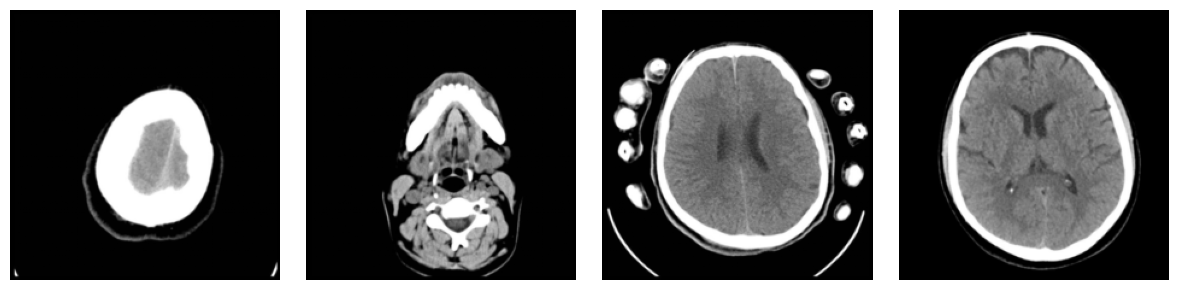

In [32]:
# Preview images using the autoencoder data pipeline
preview_images = next(iter(autoencoder_loader))

fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 3),
)

for i, ax in enumerate(axes):
    ax.imshow(
        preview_images[i, 0],
        cmap="gray",
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# Initialize the autoencoder and verify its input, latent, and output shapes
from src.autoencoder import CTICHAutoencoder

autoencoder = CTICHAutoencoder(
    latent_dim=512,
).to(device)

preview_images = preview_images.to(device)

with torch.no_grad():
    latent = autoencoder.encode(preview_images)
    reconstruction = autoencoder(preview_images)

print("Input:", preview_images.shape)
print("Latent:", latent.shape)
print("Reconstruction:", reconstruction.shape)

num_parameters = sum(
    parameter.numel()
    for parameter in autoencoder.parameters()
)

print(f"Parameters: {num_parameters:,}")

Input: torch.Size([32, 1, 224, 224])
Latent: torch.Size([32, 512])
Reconstruction: torch.Size([32, 1, 224, 224])
Parameters: 103,190,337


In [34]:
# Train the autoencoder and keep the best reconstruction model
import copy

criterion = nn.MSELoss()

optimizer = AdamW(
    autoencoder.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

num_epochs = 50

history = []
best_loss = float("inf")
best_state = None

for epoch in range(num_epochs):
    autoencoder.train()

    running_loss = 0.0

    for batch_images in autoencoder_loader:
        batch_images = batch_images.to(device)

        optimizer.zero_grad()

        reconstructions = autoencoder(batch_images)

        loss = criterion(
            reconstructions,
            batch_images,
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * batch_images.size(0)
        )

    epoch_loss = (
        running_loss / len(autoencoder_loader)
    )

    history.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = copy.deepcopy(
            autoencoder.state_dict()
        )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} "
        f"- Reconstruction loss: {epoch_loss:.6f}"
    )

autoencoder.load_state_dict(best_state)

Epoch 01/50 - Reconstruction loss: 1.979177
Epoch 02/50 - Reconstruction loss: 1.216247
Epoch 03/50 - Reconstruction loss: 0.868657
Epoch 04/50 - Reconstruction loss: 0.700598
Epoch 05/50 - Reconstruction loss: 0.605560
Epoch 06/50 - Reconstruction loss: 0.527633
Epoch 07/50 - Reconstruction loss: 0.473500
Epoch 08/50 - Reconstruction loss: 0.419901
Epoch 09/50 - Reconstruction loss: 0.377436
Epoch 10/50 - Reconstruction loss: 0.335241
Epoch 11/50 - Reconstruction loss: 0.306880
Epoch 12/50 - Reconstruction loss: 0.282865
Epoch 13/50 - Reconstruction loss: 0.261488
Epoch 14/50 - Reconstruction loss: 0.245976
Epoch 15/50 - Reconstruction loss: 0.231854
Epoch 16/50 - Reconstruction loss: 0.218606
Epoch 17/50 - Reconstruction loss: 0.205610
Epoch 18/50 - Reconstruction loss: 0.197220
Epoch 19/50 - Reconstruction loss: 0.188979
Epoch 20/50 - Reconstruction loss: 0.180676
Epoch 21/50 - Reconstruction loss: 0.170979
Epoch 22/50 - Reconstruction loss: 0.164349
Epoch 23/50 - Reconstruction los

<All keys matched successfully>

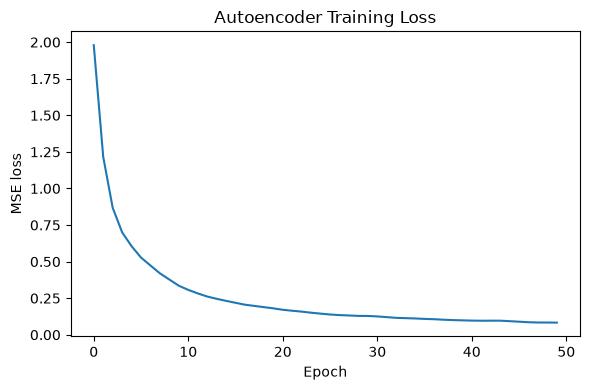

In [35]:
# Plot the autoencoder reconstruction loss
plt.figure(figsize=(6, 4))

plt.plot(history)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder Training Loss")

plt.tight_layout()
plt.show()

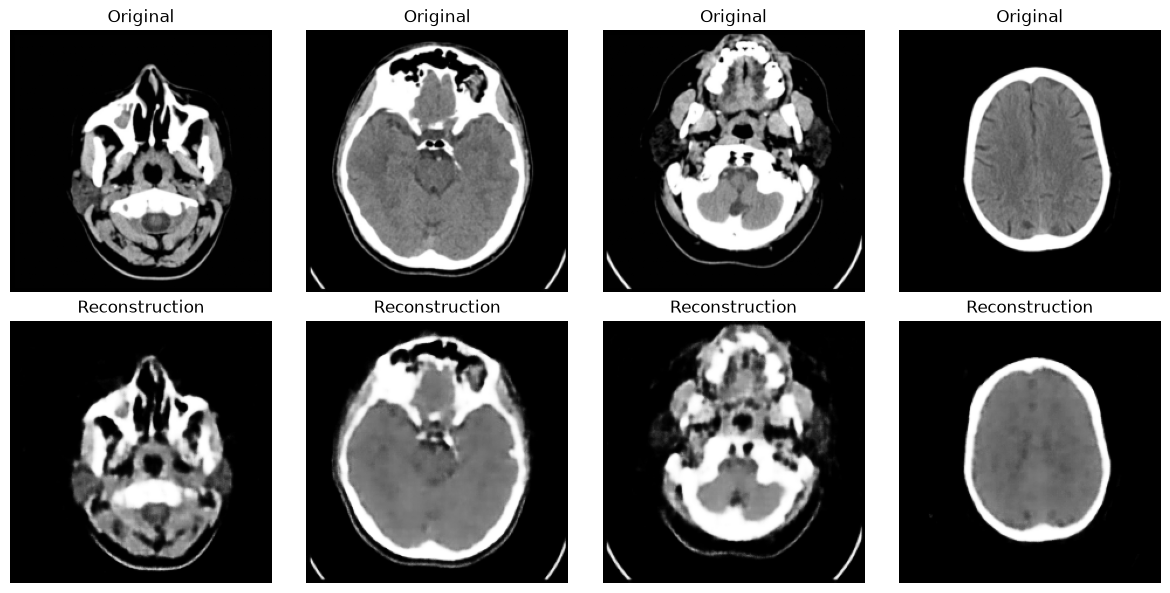

In [36]:
# Compare original CT images with their reconstructions
autoencoder.eval()

with torch.no_grad():
    reconstruction_images = next(
        iter(autoencoder_loader)
    ).to(device)

    reconstructions = autoencoder(
        reconstruction_images
    )

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6),
)

for i in range(4):
    axes[0, i].imshow(
        reconstruction_images[i, 0].cpu(),
        cmap="gray",
    )
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(
        reconstructions[i, 0].cpu(),
        cmap="gray",
    )
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstruction")

plt.tight_layout()
plt.show()

## 9.3 Latent-Space Gradient Shift & Counterfactual Generation

We encode each selected CT image into the autoencoder's latent space and compute the gradient of the classifier's ICH score with respect to the latent representation.

The latent representation is then shifted in the direction that moves the prediction toward the correct class. The shifted representation is decoded to obtain a counterfactual image.

The original image, reconstruction, and counterfactual are compared using their predicted ICH probabilities.


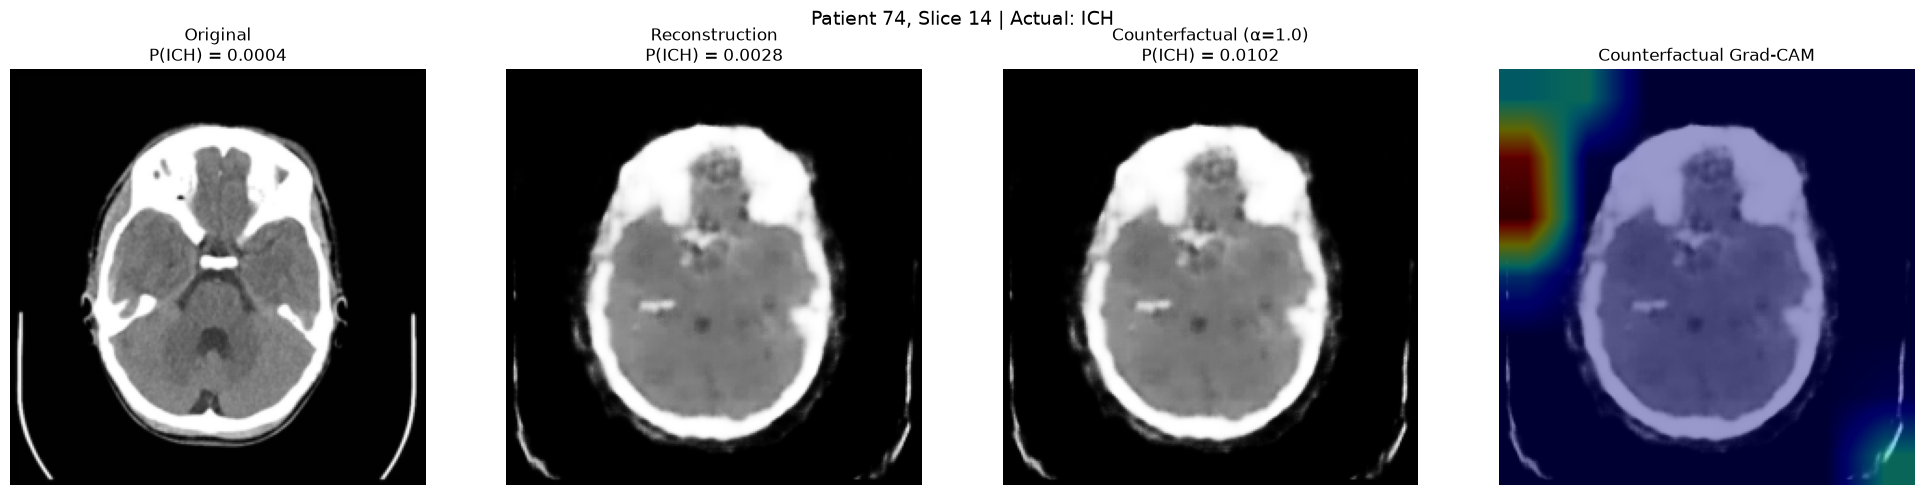

Patient 74, Slice 14
Actual: ICH
Original P(ICH):        0.0004
Reconstruction P(ICH):  0.0028
Counterfactual P(ICH):  0.0102


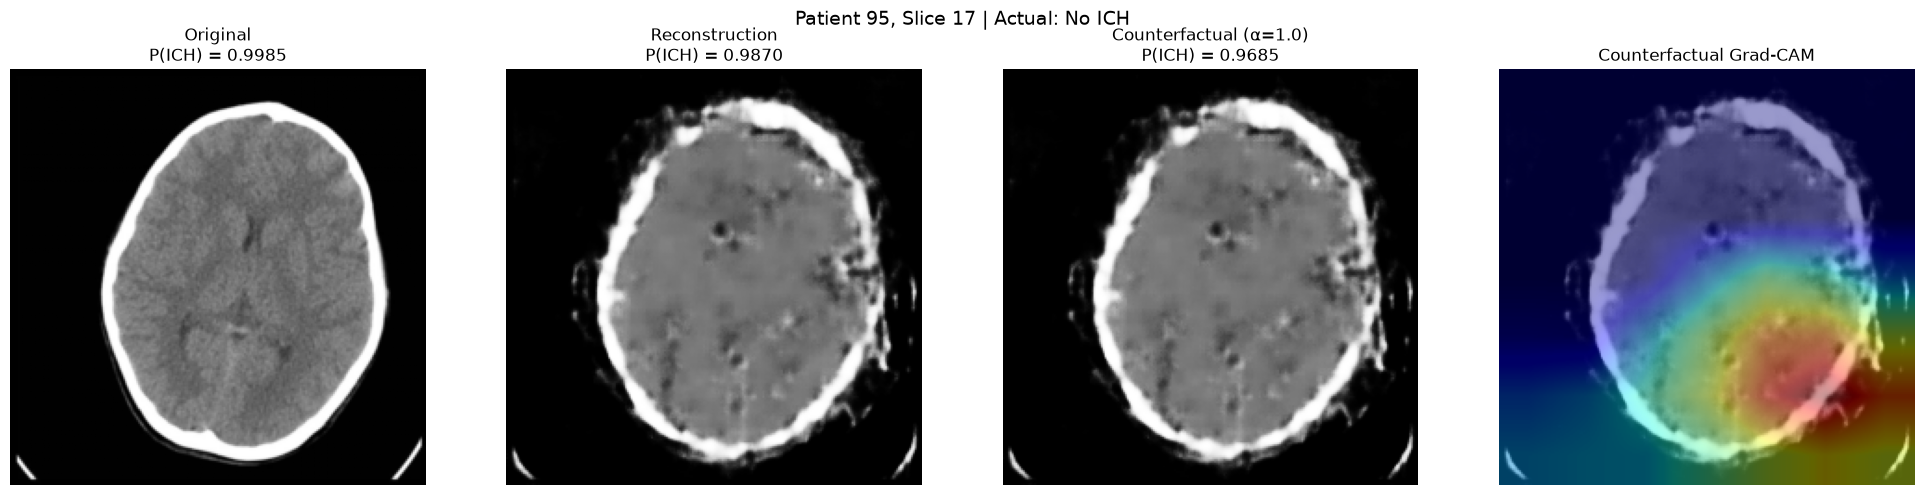

Patient 95, Slice 17
Actual: No ICH
Original P(ICH):        0.9985
Reconstruction P(ICH):  0.9870
Counterfactual P(ICH):  0.9685


In [39]:

from src.autoencoder import prepare_for_classifier

alpha = 1.0

autoencoder.eval()
model.eval()

for example in selected_errors:
    patient_id = example["patient"]
    slice_number = example["slice"]
    actual_label = example["actual_label"]

    image_pil = load_ct_image(
        DATA_DIR,
        patient_id=patient_id,
        slice_number=slice_number,
        window="brain",
    )

    image_tensor = get_autoencoder_transforms()(image_pil)
    image = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        z_original = autoencoder.encode(image)
        reconstruction = autoencoder.decode(z_original).clamp(0, 1)

    with torch.no_grad():
        original_input = prepare_for_classifier(image)
        original_logits = model(original_input)

        original_p_ich = torch.softmax(
            original_logits,
            dim=1,
        )[0, 1].item()

        reconstruction_input = prepare_for_classifier(reconstruction)
        reconstruction_logits = model(reconstruction_input)

        reconstruction_p_ich = torch.softmax(
            reconstruction_logits,
            dim=1,
        )[0, 1].item()

    z = z_original.detach().clone()
    z.requires_grad_(True)

    shifted_reconstruction = autoencoder.decode(z)
    shifted_reconstruction = shifted_reconstruction.clamp(0, 1)

    classifier_input = prepare_for_classifier(shifted_reconstruction)

    logits = model(classifier_input)

    ich_score = logits[0, 1] - logits[0, 0]
    ich_score.backward()

    gradient = z.grad

    gradient_normalized = gradient / (
        gradient.norm(
            dim=1,
            keepdim=True,
        )
        + 1e-8
    )

    if actual_label == 1:
        shift_direction = +1.0
    else:
        shift_direction = -1.0

    z_shifted = z.detach() + shift_direction * alpha * gradient_normalized.detach()

    with torch.no_grad():
        counterfactual = autoencoder.decode(z_shifted).clamp(0, 1)

        counterfactual_input = prepare_for_classifier(counterfactual)

        counterfactual_logits = model(counterfactual_input)

        counterfactual_p_ich = torch.softmax(
            counterfactual_logits,
            dim=1,
        )[0, 1].item()

    cam, _ = grad_cam.generate(
        image=counterfactual_input,
        target_class=1,
    )

    cam_resized = F.interpolate(
        cam,
        size=(224, 224),
        mode="bilinear",
        align_corners=False,
    )

    gradcam_np = cam_resized.squeeze().detach().cpu().numpy()

    original_np = image[0, 0].detach().cpu().numpy()

    reconstruction_np = reconstruction[0, 0].detach().cpu().numpy()

    counterfactual_np = counterfactual[0, 0].detach().cpu().numpy()

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5),
    )

    axes[0].imshow(
        original_np,
        cmap="gray",
    )
    axes[0].set_title(f"Original\nP(ICH) = {original_p_ich:.4f}")

    axes[1].imshow(
        reconstruction_np,
        cmap="gray",
    )
    axes[1].set_title(f"Reconstruction\nP(ICH) = {reconstruction_p_ich:.4f}")

    axes[2].imshow(
        counterfactual_np,
        cmap="gray",
    )
    axes[2].set_title(
        f"Counterfactual (α={alpha})\nP(ICH) = {counterfactual_p_ich:.4f}"
    )

    axes[3].imshow(
        counterfactual_np,
        cmap="gray",
    )
    axes[3].imshow(
        gradcam_np,
        cmap="jet",
        alpha=0.4,
    )
    axes[3].set_title("Counterfactual Grad-CAM")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"Patient {patient_id}, Slice {slice_number} | "
        f"Actual: "
        f"{'ICH' if actual_label == 1 else 'No ICH'}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

    print(f"Patient {patient_id}, Slice {slice_number}")
    print(f"Actual: {'ICH' if actual_label == 1 else 'No ICH'}")
    print(f"Original P(ICH):        {original_p_ich:.4f}")
    print(f"Reconstruction P(ICH):  {reconstruction_p_ich:.4f}")
    print(f"Counterfactual P(ICH):  {counterfactual_p_ich:.4f}")


## 9.4 Interpretation & Limitations

The latent-space exploration shows both the potential and limitations of the approach.

For **Patient 74, Slice 14**, the reconstruction does not recover the ICH signal, with P(ICH) increasing only from **0.0004** to **0.0028**. The latent shift further increases it to **0.0102**, but the prediction remains incorrect.

For **Patient 95, Slice 17**, the ICH probability decreases from **0.9985** to **0.9685** after the latent shift, but the prediction remains incorrect. The generated CT also shows limited visual fidelity.

The Grad-CAM results further show activation in the black background outside the brain, suggesting that the classifier may rely on non-pathological image regions.

Overall, the experiment shows that latent manipulation can influence the classifier output, but the current autoencoder does not produce sufficiently reliable or interpretable CT counterfactuals. The results should therefore be considered **exploratory**, with more constrained generative approaches as a potential direction for future work.


# 10. Conclusion, Limitations & Future Work

This project explored **reliable and explainable AI for brain CT imaging**, combining classification, uncertainty estimation, calibration, Grad-CAM, and latent-space perturbation. The experiments showed that overall accuracy can hide important weaknesses: the model had limited ICH sensitivity, produced some highly confident errors, and Grad-CAM sometimes highlighted regions outside the brain. The latent-space experiments also showed that a simple autoencoder may fail to preserve subtle pathological information and generate sufficiently faithful counterfactuals.

Future work should first establish the state of the art through a focused **literature review on explainable AI, generative models, and diffusion-based approaches for medical imaging**. Diffusion-based approaches could then be investigated as a potential direction for generating more controlled and higher-fidelity image variations.

On the classification side, performance could be investigated through **multi-class classification**, distinguishing the five ICH types from Non-ICH, rather than treating all ICH cases as one class. Increasing the number and diversity of patients could also improve the robustness and generalization of the model. Further experiments could evaluate different **fine-tuning strategies, model configurations, and training parameters** to better understand the current performance limitations. These experiments were not pursued here because of computational constraints.

Finally, the selected approaches should be evaluated across **different datasets and acquisition conditions**, with patient-level and external validation. Technical evaluation should also be complemented by **domain-expert feedback** to assess whether model explanations and generated counterfactuals are clinically meaningful.

Together, these steps provide a path from this exploratory work toward more rigorous research in **explainable AI, generative models, and foundation models for CT imaging**.
